In [13]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

df_final = pd.read_csv('ERBB2_clean_for_transformer.csv')

# 提取分子的Bemis-Murcko骨架
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    try:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        return scaffold
    except:
        return ""

print("开始提取骨架...")
df_final['scaffold'] = df_final['canonical_smiles'].apply(get_scaffold)

# 去掉没提取出来骨架的药化分子
df_final = df_final[df_final['scaffold'] != '']

# 把同一个骨架的分子索引记录到字典里
scaffold_dict = {}
for index, row in df_final.iterrows():
    scaf = row['scaffold']
    if scaf not in scaffold_dict:
        scaffold_dict[scaf] = []
    scaffold_dict[scaf].append(index)

# 把字典转成列表，然后根据包含的分子数量从大到小排个序
# 这样能尽量把大的骨架集放到训练集里
scaffold_list = list(scaffold_dict.items())
scaffold_list.sort(key=lambda x: len(x[1]), reverse=True)

# 只把索引列表提取出来
scaffold_sets = [item[1] for item in scaffold_list]

# 按照 8:1:1 划分训练集、验证集和训练集
total_len = len(df_final)
train_len = int(0.8 * total_len)
val_len = int(0.9 * total_len)

train_idx = []
val_idx = []
test_idx = []

# 开始划分数据
for group in scaffold_sets:
    # 训练集没分满就继续装
    if len(train_idx) + len(group) <= train_len:
        train_idx.extend(group)
    # 训练集满了，分到验证集
    elif len(train_idx) + len(val_idx) + len(group) <= val_len:
        val_idx.extend(group)
    # 剩下的都分给测试集
    else:
        test_idx.extend(group)

# 提取最终的dataframe
train_df = df_final.loc[train_idx].copy()
val_df = df_final.loc[val_idx].copy()
test_df = df_final.loc[test_idx].copy()

print("划分完成")
print("train size:", len(train_df))
print("val size:", len(val_df))
print("test size:", len(test_df))

开始提取骨架...
划分完成
train size: 1988
val size: 249
test size: 249


In [17]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer

# 1. 大厂的顶级分词器：ChemBERTa 专门用来做 AIDD 任务
# 这一步自动下载字典文件
print("正在从 HuggingFace 加载 ChemBERTa 专业化学分词器...")
# 直接让它读你本地的文件夹
tokenizer = AutoTokenizer.from_pretrained("./chemberta_vocab")
print("分词器下载完毕！")

# 2. 设定统一的参数：我们在清洗数据时设定了 150
MAX_LEN = 150
BATCH_SIZE = 32

# 3. 定义一个函数，一键把 DataFrame 的 SMILES 变成二维 Tensor 矩阵
def get_tensors_from_df(df, tokenizer, max_len):
    smiles_list = df['canonical_smiles'].tolist()
    
    # return_tensors='pt' 表示直接返回 PyTorch Tensor
    encoded_dict = tokenizer(smiles_list, 
                             padding='max_length', 
                             truncation=True, 
                             max_length=max_len, 
                             return_tensors='pt')
    
    # X 是 input_ids，y 是 pchembl_value
    # 用 pchembl_value 做回归任务，标签必须是浮点数 (FloatTensor)
    X = encoded_dict['input_ids']
    y = torch.tensor(df['pchembl_value'].values, dtype=torch.float32)
    
    return X, y

# 4. 开始将SMILES 序列转化为数字矩阵
print("正在将 SMILES 序列批量转化为数字矩阵...")
train_X, train_y = get_tensors_from_df(train_df, tokenizer, MAX_LEN)
val_X, val_y = get_tensors_from_df(val_df, tokenizer, MAX_LEN)
test_X, test_y = get_tensors_from_df(test_df, tokenizer, MAX_LEN)

# 5. TensorDataset
train_dataset = TensorDataset(train_X, train_y)
val_dataset = TensorDataset(val_X, val_y)
test_dataset = TensorDataset(test_X, test_y)

# 6. DataLoader
# 训练集打乱 shuffle=True，验证和测试集不打乱 shuffle=False！
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"训练集batch数 train_loader: {len(train_loader)}；验证集batch数 val_loader: {len(val_loader)}；测试集batch数 test_loader: {len(test_loader)}")

正在从 HuggingFace 加载 ChemBERTa 专业化学分词器...
分词器下载完毕！
正在将 SMILES 序列批量转化为数字矩阵...
训练集batch数 train_loader: 63；验证集batch数 val_loader: 8；测试集batch数 test_loader: 8


In [20]:
import torch
import torch.nn as nn

# 构建 CNN-Transformer 模型 (使用 nn.Embedding 位置编码)
class SmilesTransformerCNN(nn.Module):
    # max_len=150
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4, cnn_kernel_size=3, dropout=0.1, max_len=150):
        super().__init__()
        self.model_type = 'Transformer'
        self.d_model = d_model

        # 1. 输入 Embedding 层 (负责把化学字符变成向量)
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # 2. 可学习的位置编码 (用极简的 Embedding 替代 sin/cos)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

        # 3. 前置 CNN 特征提取层 (提取特征，官能团)
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(in_channels=d_model, 
                      out_channels=d_model, 
                      kernel_size=cnn_kernel_size, 
                      padding=cnn_kernel_size//2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # 4. Transformer 编码器层 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, 
                                                  nhead=nhead, 
                                                  dim_feedforward=d_model*4, 
                                                  dropout=dropout, 
                                                  activation='relu',
                                                  batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 5. 输出回归头 
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )
        self._init_weights()

    def _init_weights(self):
        initrange = 0.1
        self.embedding.weight.data.uniform_(-initrange, initrange)
        # 新加的位置编码层初始化
        self.pos_embedding.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        # 获取当前批次的序列长度 (假设经过截断补齐后是 150)
        batch_size, seq_len = src.size()

        # 1. 词向量: [Batch, Seq_Len] -> [Batch, Seq_Len, d_model]
        output = self.embedding(src)

        # 2. CNN 特征提取 (记得转换维度给 Conv1d )
        output = output.permute(0, 2, 1) 
        output = self.cnn_extractor(output) 
        output = output.permute(0, 2, 1) 

        # 3. 可学习的位置编码
        # 生成一个 [0, 1, 2... seq_len-1] 的位置序号列表
        positions = torch.arange(0, seq_len, device=src.device).unsqueeze(0) # 形状变成 [1, Seq_Len]
        
        # 把序号扔进 pos_embedding 查表，得到位置向量
        pos_emb = self.pos_embedding(positions) # 形状: [1, Seq_Len, d_model]
        
        # 词向量和位置向量直接相加，然后 Dropout 防过拟合
        output = output + pos_emb
        output = self.dropout(output)

        # 4. 扔进 Transformer 
        output = self.transformer_encoder(output)

        # 5. 全局平均池化 (把整个句子的特征压缩成一个向量)
        output = torch.mean(output, dim=1)

        # 6. 回归头输出最终的 pChEMBL 数值
        output = self.output_head(output)
        
        # 去掉多余的维度，变成一维列表返回，方便后面算 Loss
        return output.squeeze(-1)

print("可学习位置编码版 CNN-Transformer 模型构建完成！")

############# 实例化模型
# 核心参数
# vocab_size 必须从分词器里拿，这是防止维度爆炸的关键！
VOCAB_SIZE = tokenizer.vocab_size 
D_MODEL = 256    # 稠密向量维度 (256 或 512，越大模型越强但越慢)
NHEAD = 8        # 注意力头数 (必须能被 d_model 整除)
NUM_LAYERS = 4   # Transformer 堆叠层数 (先设小点，防过拟合)

# 实例化
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

model = SmilesTransformerCNN(vocab_size=VOCAB_SIZE, 
                             d_model=D_MODEL, 
                             nhead=NHEAD, 
                             num_layers=NUM_LAYERS)
model = model.to(device)
print("模型实例化成功...")

可学习位置编码版 CNN-Transformer 模型构建完成！
当前使用的计算设备: cpu
模型实例化成功...


In [25]:
import torch.optim as optim
import time

# 1. 超参数配置
EPOCHS = 20            # 训练轮数
PATIENCE = 5           # 早停容忍度（连续 5 轮没进步就停）
LEARNING_RATE = 1e-4    # Transformer 比较敏感，学习率不能太大

# HuberLoss (对离群的神药数据极其宽容)
criterion = nn.HuberLoss(delta=1.0)

# 使用 AdamW 而不是 Adam (带权重衰减，防止模型死记硬背)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 动态学习率调度器：如果验证集 Loss 连续 5 轮不降，学习率直接砍半
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

best_val_loss = float('inf')  # 因为是算误差 Loss，所以越小越好，初始值设为无穷大
early_stop_counter = 0

# 2. 开启训练
print("开始训练 CNN-Transformer 模型...")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    model.train() # 开启 Dropout 和 BatchNorm
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 1. 梯度清零
        optimizer.zero_grad()
        
        # 2. 前向传播 (模型做出预测)
        predictions = model(batch_X)
        
        # 3. 计算误差
        loss = criterion(predictions, batch_y)
        
        # 4. 反向传播 (计算梯度)
        loss.backward()
        
        # 梯度裁剪！(防止 Transformer 梯度爆炸导致 Loss 变成 NaN)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 5. 更新权重
        optimizer.step()
        
        # 累加这一批次的误差 (乘以批次大小还原真实总量)
        train_loss += loss.item() * batch_X.size(0)
        
    # 计算整个 Epoch 的平均训练误差
    avg_train_loss = train_loss / len(train_loader.dataset)
    
    # 验证阶段
    model.eval() # 关闭 Dropout
    val_loss = 0.0
    
    with torch.no_grad(): # 不计算梯度，省显存！
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    avg_val_loss = val_loss / len(val_loader.dataset)
    
    # 学习率更新
    scheduler.step(avg_val_loss)
 
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        print(f"Val Loss 从 {best_val_loss:.4f} 降至 {avg_val_loss:.4f}！保存最优模型...")
        best_val_loss = avg_val_loss
        early_stop_counter = 0 # 计数器清零
        
        # 保存最优模型
        torch.save(model.state_dict(), 'best_erbb2_cnn_transformer.pth') 
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print(f"连续 {PATIENCE} 个 Epoch 验证集无变化，触发早停机制 (Early Stopping)！避免过拟合。")
            break

print(f"训练结束！SMILES 的 ERBB2 预测大模型的最佳 Val Loss 为: {best_val_loss:.4f}")

开始训练 CNN-Transformer 模型...
Epoch 1/20 | Train Loss: 0.3642 | Val Loss: 0.5071
Val Loss 从 inf 降至 0.5071！保存最优模型...
Epoch 2/20 | Train Loss: 0.3483 | Val Loss: 0.4335
Val Loss 从 0.5071 降至 0.4335！保存最优模型...
Epoch 3/20 | Train Loss: 0.3523 | Val Loss: 0.4789
Epoch 4/20 | Train Loss: 0.3523 | Val Loss: 0.4276
Val Loss 从 0.4335 降至 0.4276！保存最优模型...
Epoch 5/20 | Train Loss: 0.3566 | Val Loss: 0.5642
Epoch 6/20 | Train Loss: 0.3353 | Val Loss: 0.5023
Epoch 7/20 | Train Loss: 0.3486 | Val Loss: 0.4357
Epoch 8/20 | Train Loss: 0.3195 | Val Loss: 0.4153
Val Loss 从 0.4276 降至 0.4153！保存最优模型...
Epoch 9/20 | Train Loss: 0.3039 | Val Loss: 0.4316
Epoch 10/20 | Train Loss: 0.2927 | Val Loss: 0.3929
Val Loss 从 0.4153 降至 0.3929！保存最优模型...
Epoch 11/20 | Train Loss: 0.3098 | Val Loss: 0.3551
Val Loss 从 0.3929 降至 0.3551！保存最优模型...
Epoch 12/20 | Train Loss: 0.2881 | Val Loss: 0.4028
Epoch 13/20 | Train Loss: 0.2814 | Val Loss: 0.3773
Epoch 14/20 | Train Loss: 0.2785 | Val Loss: 0.4577
Epoch 15/20 | Train Loss: 0.2

正在加载最佳模型...
对测试集的预测...
MAE (平均绝对误差): 0.8658
MSE (均方误差):     1.1915
Pearson r (相关性): 0.6271
R² (决定系数):      0.2398


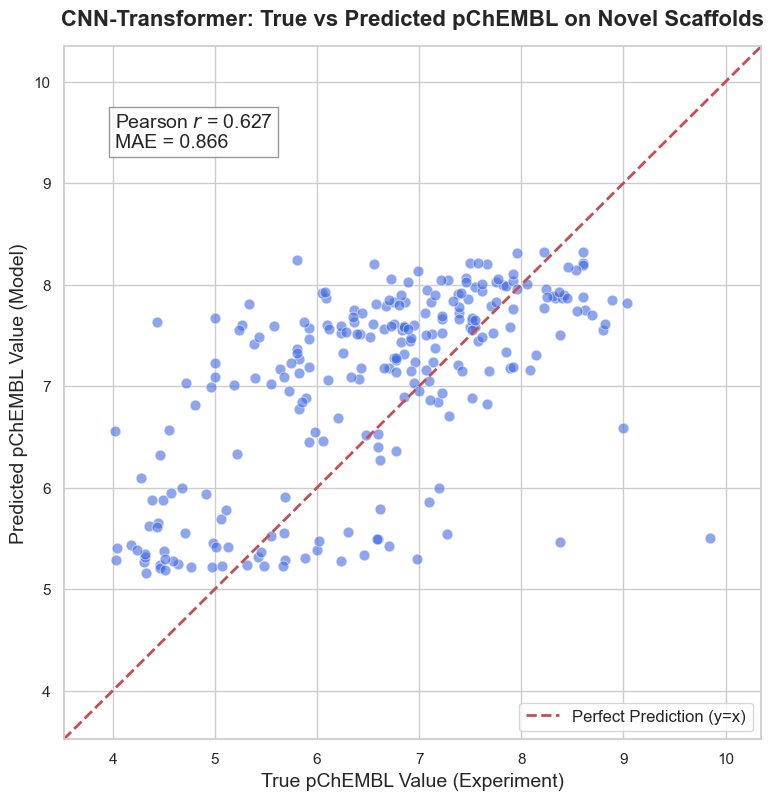

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# 1. 加载最佳模型
print("正在加载最佳模型...")
# 确保model 实例还在内存里，如果没有，需要重新实例化一遍 SmilesTransformerCNN
model.load_state_dict(torch.load('best_erbb2_cnn_transformer.pth', map_location=device, weights_only=True))
model.eval() #关闭 Dropout

# ==========================================
# 2. 在测试集上最终预测
# ==========================================
all_preds = []
all_trues = []

print("对测试集的预测...")
with torch.no_grad(): # 不计算梯度
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        # 输出预测值
        preds = model(batch_X)
        
        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(batch_y.numpy())

# 转成 numpy 数组
all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

# 3. 计算Metrics
# MAE (平均绝对误差): 预测值和真实值平均差了多少个数量级
mae = mean_absolute_error(all_trues, all_preds)

# MSE (均方误差): 对偏离过大的预测会有极高的惩罚
mse = mean_squared_error(all_trues, all_preds)

# Pearson r (皮尔逊相关系数): 评估预测排名是否准确
pearson_r, _ = pearsonr(all_trues, all_preds)

# R2 Score (决定系数): 评估模型对数据变异的解释程度 (满分1.0)
r2 = r2_score(all_trues, all_preds)

print(f"MAE (平均绝对误差): {mae:.4f}")
print(f"MSE (均方误差):     {mse:.4f}")
print(f"Pearson r (相关性): {pearson_r:.4f}")
print(f"R² (决定系数):      {r2:.4f}")

# 4. 绘制散点图 (Scatter Plot)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 9))

# 画出预测值 vs 真实值的散点
sns.scatterplot(x=all_trues, y=all_preds, alpha=0.6, color='royalblue', edgecolor='w', s=60)

# 画一条 y=x 的完美预测虚线 (对角线)
# 如果所有的点都精准落在这条线上，说明模型是 100% 成功
min_val = min(min(all_trues), min(all_preds)) - 0.5
max_val = max(max(all_trues), max(all_preds)) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')

# 标注一下模型指标
plt.text(min_val + 0.5, max_val - 1.0, f"Pearson $r$ = {pearson_r:.3f}\nMAE = {mae:.3f}", 
         fontsize=14, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# 设置坐标轴标签和标题
plt.title('CNN-Transformer: True vs Predicted pChEMBL on Novel Scaffolds', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('True pChEMBL Value (Experiment)', fontsize=14)
plt.ylabel('Predicted pChEMBL Value (Model)', fontsize=14)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(loc='lower right', fontsize=12)

# 展示图表
plt.show()